# Week 8 · Day 3 — Practice
# Capstone Dry-Run: Full Pipeline on the Titanic 🚢

Before your graded capstone, let's rehearse the **whole pipeline once more** on a familiar dataset — the Titanic. Same 7 stages we did in class:

**Problem → Load → Clean → Explore → Visualize → Model → Result**

Fill in each `# YOUR CODE HERE`. This is your template for the assignment.

In [1]:
# Toolkit + data (run as-is)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Stage 1 — Problem statement

Double-click and write your question in one sentence.
*Example: "Can we predict whether a passenger survived from their class, sex, age, and fare?"*

*Your problem statement:*


### Stage 2 — Load & inspect

Print the shape and the missing-value counts.

In [2]:
# print shape
# YOUR CODE HERE
print("Shape: ", titanic.shape)
print()
# missing values per column
# YOUR CODE HERE
titanic.isnull().sum()


Shape:  (891, 15)



survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### Stage 3 — Clean

- Make a `.copy()` into `df` keeping columns: `pclass`, `sex`, `age`, `fare`, `survived`
- Fill missing `age` with the median
- Map `sex`: male → 0, female → 1

In [3]:
df = titanic[["pclass", "sex", "age", "fare", "survived"]].copy()

# fill missing age with median
# YOUR CODE HERE
df["age"] = df["age"].fillna(df["age"].median())

# map sex to numbers
# YOUR CODE HERE
df["sex"] = df["sex"].map({"male": 0, "female": 1})
df.isnull().sum()

pclass      0
sex         0
age         0
fare        0
survived    0
dtype: int64

### Stage 4–5 — Explore & visualize

Show survival counts, then draw any one plot that explores the data (e.g. a countplot of `survived` by `sex`).

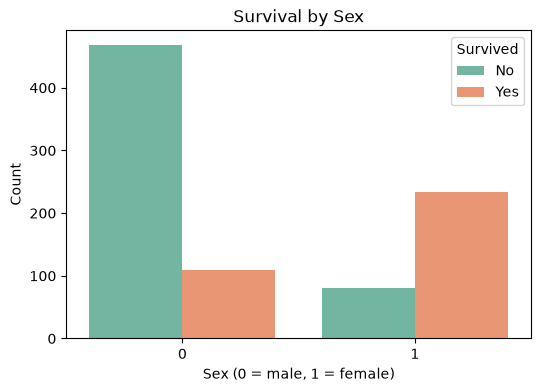

In [8]:
# survival counts
# YOUR CODE HERE
df["survived"].value_counts()


# one exploratory plot
# YOUR CODE HERE
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sex", hue="survived", palette="Set2")
plt.title("Survival by Sex")
plt.xlabel("Sex (0 = male, 1 = female)")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()


### Stage 6 — Model (the 5-step recipe)

Features = `pclass, sex, age, fare`; target = `survived`. Split 20% test, train KNN (k=5), predict, print accuracy.

In [9]:
features = ["pclass", "sex", "age", "fare"]
X = df[features]
y = df["survived"]

# split, train, predict, score
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = KNeighborsClassifier(n_neighbors=8)
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

# Score
acc = accuracy_score(y_test, preds)
print(f"Accuracy: {acc*100:.1f}%")



Accuracy: 70.9%


### Stage 7 — Result write-up

Double-click and write 2–3 sentences: what accuracy did you get, and what does it mean?

*Your result:*
